# Waze IA: rutas en La Estrella

Este cuaderno aplica A* propio sobre la red vial de La Estrella, Antioquia. Reutiliza el flujo de localización, tablas geográficas y visualización trabajado en clase, pero conserva el modelo de costos por tipo de vía, intersecciones y giros.


## 1. Importaciones y mapa

La red se descarga como un grafo dirigido para vehículos. NetworkX solo se usa para representar y consultar el grafo: la búsqueda de rutas se implementa más adelante con A*.


In [44]:
import os
from pathlib import Path
from urllib.parse import urlencode
import heapq
import math
import time

import geopandas as gpd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd
import plotly.graph_objects as go
from geopy.geocoders import Nominatim
from IPython.display import HTML, clear_output, display
from shapely.geometry import LineString

pd.set_option("display.max_columns", None)


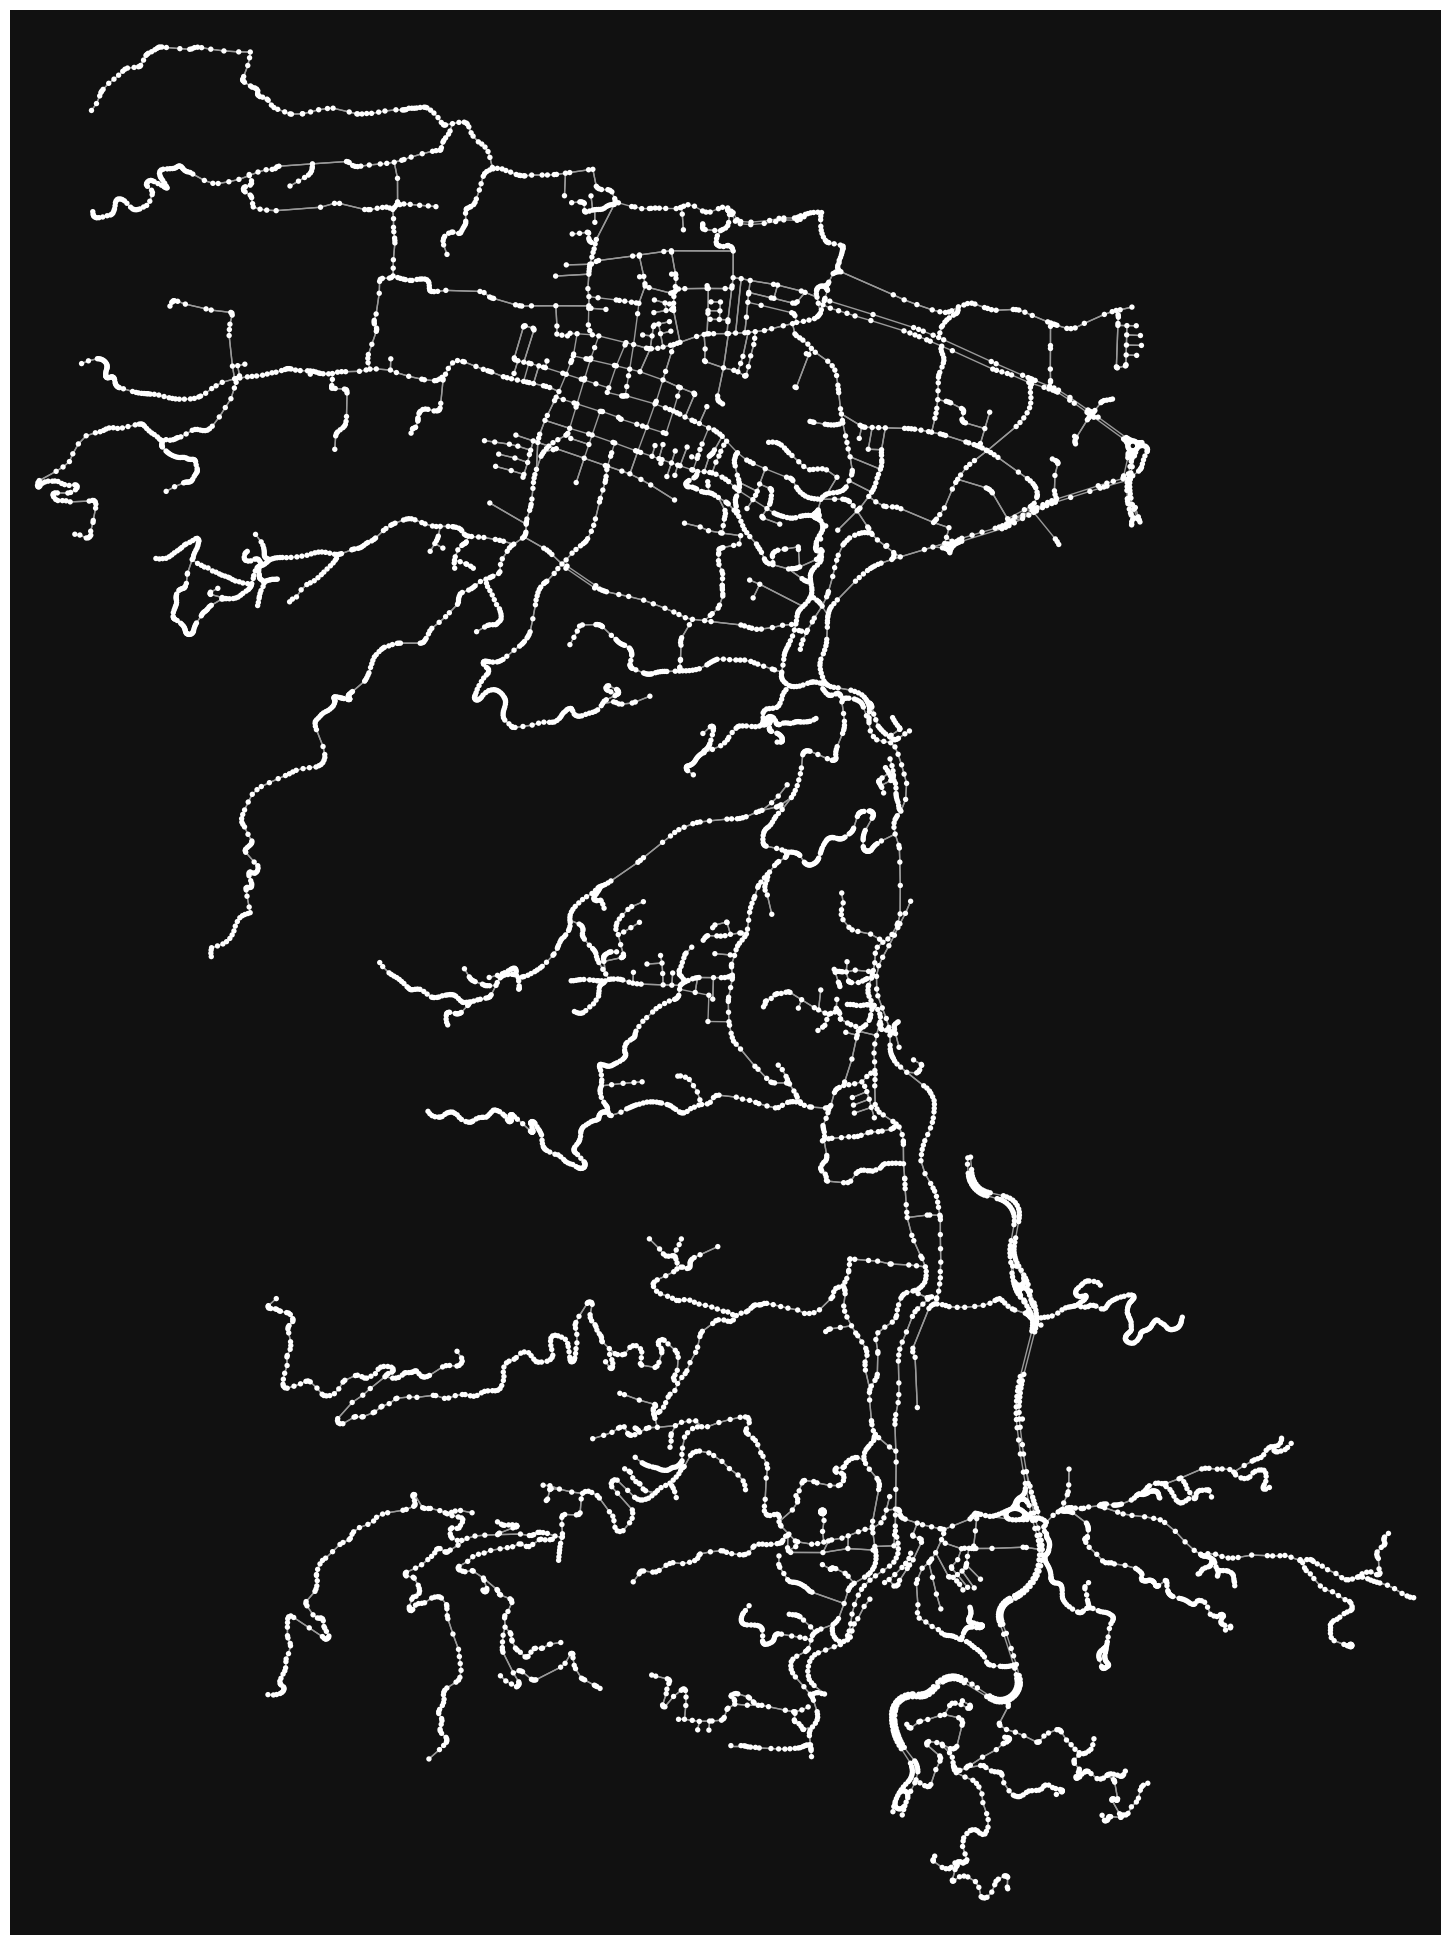

(<Figure size 2500x2500 with 1 Axes>, <Axes: >)

In [45]:
G = ox.graph_from_place('La Estrella, Antioquia, Colombia', network_type='drive', simplify=False)
ox.plot_graph(G, figsize=(25, 25))

## 2. Información del mapa y tiempos de viaje

Se convierten los nodos y aristas a tablas geográficas y se calculan velocidades y tiempos de viaje, igual que en el ejemplo de clase.


In [46]:
hwy_speeds = {
    'motorway': 80,
    'trunk': 60,
    'primary': 50,
    'secondary': 40,
    'tertiary': 35,
    'residential': 30,
    'unclassified': 30,
    'service': 20
}

hwy_speeds

{'motorway': 80,
 'trunk': 60,
 'primary': 50,
 'secondary': 40,
 'tertiary': 35,
 'residential': 30,
 'unclassified': 30,
 'service': 20}

In [47]:
G = ox.add_edge_speeds(G, hwy_speeds=hwy_speeds)
G = ox.add_edge_travel_times(G)
G = ox.add_edge_bearings(G)

print('Velocidades, tiempos de viaje y orientaciones calculados correctamente.')

Velocidades, tiempos de viaje y orientaciones calculados correctamente.


In [48]:
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_edges.head()

osmid     highway lanes maxspeed  \
u         v           key                                          
322010859 11933215278 0     440843501       trunk     3       80   
322010907 9369408441  0     384110369       trunk     2       80   
          9392365640  0    1018297125  trunk_link     1      NaN   
322010909 11933215257 0     384110369       trunk     2       80   
322010911 4121909108  0     384110369       trunk     2       80   

                                         name  oneway  ref  reversed  \
u         v           key                                              
322010859 11933215278 0    Avenida Carrera 42    True   25     False   
322010907 9369408441  0    Avenida Carrera 42    True   25     False   
          9392365640  0                   NaN    True  NaN     False   
322010909 11933215257 0    Avenida Carrera 42    True   25     False   
322010911 4121909108  0    Avenida Carrera 42    True   25     False   

                              length  speed_kph  travel_time     bearing  \
u         v           key                                                  
322010859 11933215278 0    19.641968  80.000000     0.883889  244.983211   
322010907 9369408441  0    35.111248  80.000000     1.580006  242.070184   
          9392365640  0    37.208254  40.318182     3.322315  257.995064   
322010909 11933215257 0    20.267521  80.000000     0.912038  247.279246   
322010911 4121909108  0    60.862245  80.000000     2.738801  252.520912   

                          bridge width junction access  \
u         v           key                                
322010859 11933215278 0      NaN   NaN      NaN    NaN   
322010907 9369408441  0      NaN   NaN      NaN    NaN   
          9392365640  0      NaN   NaN      NaN    NaN   
322010909 11933215257 0      NaN   NaN      NaN    NaN   
322010911 4121909108  0      NaN   NaN      NaN    NaN   

                                                                    geometry  
u         v           key                                                     
322010859 11933215278 0    LINESTRING (-75.62853 6.15432, -75.62869 6.15424)  
322010907 9369408441  0    LINESTRING (-75.62939 6.15377, -75.62967 6.15363)  
          9392365640  0     LINESTRING (-75.62939 6.15377, -75.62972 6.1537)  
322010909 11933215257 0    LINESTRING (-75.62839 6.15428, -75.62856 6.15421)  
322010911 4121909108  0    LINESTRING (-75.62774 6.15449, -75.62826 6.15433)

In [49]:
gdf_edges.explode('highway').groupby('highway')[['length', 'speed_kph', 'travel_time']].mean().round(1)

,length,speed_kph,travel_time
highway,,,
residential,16.9,30.0,2.0
secondary,22.4,39.7,2.1
secondary_link,7.2,30.0,0.9
tertiary,20.5,33.4,2.3
tertiary_link,6.1,28.2,0.8
trunk,18.8,40.5,1.8
trunk_link,11.2,40.3,1.0
unclassified,18.7,30.0,2.2


## 3. Lugares estandarizados y seleccion general

La ruta no queda fijada a un par de lugares. El selector al final del cuaderno usa coordenadas estandarizadas, por lo que A*, Google Maps y Waze pueden recibir el mismo punto geografico.


In [50]:
# Menu de lugares estandarizados. Las coordenadas son la fuente de verdad.
# Para agregar otro sitio, incluya una nueva entrada con nombre, latitud y longitud,
# y ejecute esta celda y la celda del selector nuevamente.
LUGARES_VALIDOS = {
    "comfama": {
        "nombre": "Parque Comfama La Estrella",
        "lat": 6.1543088,
        "lon": -75.6531261,
    },
    "hospital": {
        "nombre": "Hospital La Estrella",
        "lat": 6.1554390,
        "lon": -75.6440655,
    },
    "cocorollo": {
        "nombre": "Cocorollo La Estrella",
        "lat": 6.1171245,
        "lon": -75.6303483,
    },
    "tablaza": {
        "nombre": "Centro de La Tablaza",
        "lat": 6.1181940,
        "lon": -75.6351392,
    },
}

MAX_SNAP_DISTANCE_M = 250
MAP_BOUNDS = gdf_nodes.total_bounds  # min_lon, min_lat, max_lon, max_lat
pd.DataFrame.from_dict(LUGARES_VALIDOS, orient="index")


,nombre,lat,lon
comfama,Parque Comfama La Estrella,6.154309,-75.653126
hospital,Hospital La Estrella,6.155439,-75.644065
cocorollo,Cocorollo La Estrella,6.117125,-75.630348
tablaza,Centro de La Tablaza,6.118194,-75.635139


La seleccion de A y B se realiza mediante el menu interactivo de la seccion 8.

La seleccion de A y B se realiza mediante el menu interactivo de la seccion 8.

La seleccion de A y B se realiza mediante el menu interactivo de la seccion 8.

La seleccion de A y B se realiza mediante el menu interactivo de la seccion 8.

La seleccion de A y B se realiza mediante el menu interactivo de la seccion 8.

## 4. A* propio

Cada estado representa un nodo de la red vial. La implementación respeta vías dirigidas y aristas paralelas, y no usa algoritmos de rutas de NetworkX.


In [51]:
class OSMRouteMap:
    """
    Consultas, costos y heurística para una red vial dirigida
    obtenida de OpenStreetMap mediante OSMnx.

    La función objetivo es minimizar el tiempo estimado de viaje
    en automóvil.
    """

    def __init__(self, graph, config=None):
        self.graph = graph
        self.config = dict(config) if config is not None else {}

        # La velocidad de referencia nunca puede ser menor que la
        # velocidad máxima real del grafo, porque la heurística
        # podría dejar de ser admisible.
        graph_max_speed_kph = self._maximum_speed_kph()

        if 'max_speed_kph' in self.config:
            self.max_speed_kph = float(self.config['max_speed_kph'])
        else:
            self.max_speed_kph = graph_max_speed_kph

        if (
            not math.isfinite(self.max_speed_kph)
            or self.max_speed_kph <= 0
        ):
            raise ValueError(
                'max_speed_kph debe ser un número positivo.'
            )

        if self.max_speed_kph < graph_max_speed_kph:
            raise ValueError(
                'max_speed_kph debe ser igual o superior a la '
                'velocidad máxima del grafo '
                f'({graph_max_speed_kph:.1f} km/h).'
            )

    @staticmethod
    def _as_numbers(value):
        """
        Convierte valores simples o listas de OSM en números válidos.

        OSM puede almacenar algunos atributos como:
            30
            '30'
            ['30', '40']
        """
        values = (
            value
            if isinstance(value, (list, tuple))
            else [value]
        )

        numbers = []

        for item in values:
            try:
                number = float(item)
            except (TypeError, ValueError):
                continue

            if math.isfinite(number):
                numbers.append(number)

        return numbers

    def _maximum_speed_kph(self):
        """
        Obtiene la mayor velocidad válida presente en las aristas.

        Esta velocidad se utiliza como referencia para construir
        la heurística temporal.
        """
        speeds = []

        for _, _, edge_data in self.graph.edges(data=True):
            speeds.extend(
                self._as_numbers(
                    edge_data.get('speed_kph')
                )
            )

        if not speeds:
            raise ValueError(
                'El grafo no contiene valores válidos de speed_kph.'
            )

        return max(speeds)

    def neighbors(self, node_id):
        """
        Devuelve las aristas salientes de node_id.

        Cada elemento tiene la forma:

            (neighbor_id, key, edge_data)

        Se utilizan out_edges() y keys=True para:
        - respetar el sentido de circulación;
        - conservar las aristas paralelas.
        """
        return [
            (neighbor_id, key, edge_data)
            for _, neighbor_id, key, edge_data
            in self.graph.out_edges(
                node_id,
                keys=True,
                data=True
            )
        ]

    def edge_travel_cost(
        self,
        u,
        v,
        key,
        edge_data
    ):
        """
        Devuelve el costo de recorrer una arista en segundos.

        El costo corresponde directamente a travel_time,
        calculado previamente por OSMnx.
        """
        travel_times = self._as_numbers(
            edge_data.get('travel_time')
        )

        if not travel_times:
            raise ValueError(
                f'La arista ({u}, {v}, {key}) '
                'no tiene un travel_time válido.'
            )

        travel_time = travel_times[0]

        if travel_time < 0:
            raise ValueError(
                f'La arista ({u}, {v}, {key}) '
                'tiene un costo negativo.'
            )

        return travel_time

    def heuristic(self, node_id, destination_id):
        """
        Estima en segundos el tiempo mínimo restante desde
        node_id hasta destination_id.

        La estimación se obtiene mediante:

            distancia en línea recta / velocidad máxima

        La distancia se calcula mediante la fórmula de Haversine.

        Utilizar la distancia en línea recta proporciona una
        distancia mínima posible entre ambos nodos. Utilizar la
        velocidad máxima proporciona el menor tiempo físicamente
        posible bajo el modelo utilizado.

        Por tanto, la heurística no sobreestima el tiempo real
        de viaje y es admisible para A* bajo este modelo.
        """
        if node_id == destination_id:
            return 0.0

        origin = self.graph.nodes[node_id]
        destination = self.graph.nodes[destination_id]

        # Coordenadas geográficas de los nodos.
        lat1 = math.radians(origin['y'])
        lon1 = math.radians(origin['x'])

        lat2 = math.radians(destination['y'])
        lon2 = math.radians(destination['x'])

        # Diferencias angulares.
        delta_lat = lat2 - lat1
        delta_lon = lon2 - lon1

        # Fórmula de Haversine.
        a = (
            math.sin(delta_lat / 2) ** 2
            + math.cos(lat1)
            * math.cos(lat2)
            * math.sin(delta_lon / 2) ** 2
        )

        # Evita pequeños errores numéricos fuera del intervalo [0, 1].
        a = min(1.0, max(0.0, a))

        earth_radius_m = 6_371_008.8

        distance_m = (
            2
            * earth_radius_m
            * math.asin(math.sqrt(a))
        )

        # Conversión:
        #
        # distancia_m / (km/h)
        # ->
        # segundos
        #
        # 1 km/h = 1/3.6 m/s
        estimated_time_s = (
            distance_m * 3.6 / self.max_speed_kph
        )

        return estimated_time_s

    def a_star(self, start_id, destination_id):
        """
        Encuentra una ruta de costo temporal mínimo mediante A*.

        La frontera utiliza heapq y ordena los estados por:

            f(n) = g(n) + h(n)

        El resultado contiene la ruta, su costo y métricas de la
        búsqueda. Si no existe una ruta, found es False.
        """
        if start_id not in self.graph:
            raise ValueError(
                f'El nodo de origen {start_id} no existe en el grafo.'
            )

        if destination_id not in self.graph:
            raise ValueError(
                f'El nodo de destino {destination_id} no existe en el grafo.'
            )

        started_at = time.perf_counter()

        # Cada entrada contiene:
        # (f_score, g_al_insertar, contador, node_id)
        # El contador evita comparar identificadores en caso de empate.
        frontier = []
        push_counter = 0

        g_score = {start_id: 0.0}
        came_from = {}
        explored_nodes = set()

        initial_f = self.heuristic(start_id, destination_id)
        heapq.heappush(
            frontier,
            (initial_f, 0.0, push_counter, start_id)
        )

        while frontier:
            _, queued_g, _, current = heapq.heappop(frontier)

            # Una mejora posterior puede dejar entradas antiguas
            # dentro del heap. Esas entradas se descartan aquí.
            if queued_g > g_score.get(current, math.inf):
                continue

            explored_nodes.add(current)

            if current == destination_id:
                route_nodes, route_edges = self.reconstruct_route(
                    came_from,
                    destination_id
                )

                return {
                    'found': True,
                    'route_nodes': route_nodes,
                    'route_edges': route_edges,
                    'total_cost_s': g_score[destination_id],
                    'explored_nodes': len(explored_nodes),
                    'elapsed_time_s': time.perf_counter() - started_at,
                    'message': 'Ruta encontrada.'
                }

            for neighbor, key, edge_data in self.neighbors(current):
                step_cost = self.edge_travel_cost(
                    current,
                    neighbor,
                    key,
                    edge_data
                )
                tentative_g = queued_g + step_cost

                if tentative_g < g_score.get(neighbor, math.inf):
                    g_score[neighbor] = tentative_g
                    came_from[neighbor] = (current, key)

                    push_counter += 1
                    estimated_f = (
                        tentative_g
                        + self.heuristic(neighbor, destination_id)
                    )
                    heapq.heappush(
                        frontier,
                        (
                            estimated_f,
                            tentative_g,
                            push_counter,
                            neighbor
                        )
                    )

        return {
            'found': False,
            'route_nodes': [],
            'route_edges': [],
            'total_cost_s': math.inf,
            'explored_nodes': len(explored_nodes),
            'elapsed_time_s': time.perf_counter() - started_at,
            'message': (
                f'No existe una ruta dirigida entre {start_id} '
                f'y {destination_id}.'
            )
        }

    def reconstruct_route(
        self,
        came_from,
        destination_id
    ):
        """
        Reconstruye los nodos y las aristas desde el destino.

        came_from guarda para cada nodo:

            node_id -> (predecessor_id, edge_key)
        """
        route_nodes = [destination_id]
        route_edges = []
        current = destination_id

        while current in came_from:
            predecessor, key = came_from[current]
            route_edges.append((predecessor, current, key))
            current = predecessor
            route_nodes.append(current)

        route_nodes.reverse()
        route_edges.reverse()

        return route_nodes, route_edges

La ejecucion de A* se realiza al seleccionar los puntos A y B en la seccion 8.

## 5. Validación y costos compuestos

Primero se verifica A* contra costo uniforme propio. Después se ejecutan los cuatro perfiles de costo: tiempo base, tipo de vía, intersecciones y giros.


In [52]:
def validate_composite_route(result, start_id, end_id):
    """Verifica la ruta producida por A* antes de mostrarla."""
    if not result["found"]:
        raise ValueError(result["message"])

    nodes = result["route_nodes"]
    edges = result["route_edges"]
    details = result["edge_details"]
    if nodes[0] != start_id or nodes[-1] != end_id:
        raise AssertionError("La ruta no coincide con los nodos seleccionados.")
    if len(edges) != len(nodes) - 1 or len(details) != len(edges):
        raise AssertionError("La estructura de la ruta es inconsistente.")
    if any(detail["total_edge_cost_s"] < 0 for detail in details):
        raise AssertionError("La ruta contiene un costo negativo.")
    if not math.isclose(
        sum(detail["total_edge_cost_s"] for detail in details),
        result["total_cost_s"], rel_tol=1e-10, abs_tol=1e-7,
    ):
        raise AssertionError("El costo total no coincide con la suma de tramos.")


def summarize_composite_result(result):
    details = pd.DataFrame(result["edge_details"])
    return pd.Series({
        "Distancia total (km)": details["length_m"].sum() / 1000,
        "Tiempo base (min)": details["base_time_s"].sum() / 60,
        "Costo estimado A* (min)": result["total_cost_s"] / 60,
        "Ajuste tipo de via (s)": details["highway_adjustment_s"].sum(),
        "Demora intersecciones (s)": details["intersection_adjustment_s"].sum(),
        "Demora giros (s)": details["turn_adjustment_s"].sum(),
        "Nodos explorados": result["explored_nodes"],
        "Tiempo de busqueda (s)": result["elapsed_time_s"],
    }).round(3)


In [53]:
class UniformCostRouteMap(OSMRouteMap):
    """Version de validacion: equivale a A* con h(n) = 0."""

    def heuristic(self, node_id, destination_id):
        return 0.0


In [54]:
class CompositeOSMRouteMap(OSMRouteMap):
    """A* propio con costo temporal compuesto y estado ampliado."""

    DEFAULT_CONFIG = {
        'highway_speeds_kph': {
            'motorway': 80.0,
            'trunk': 60.0,
            'primary': 50.0,
            'secondary': 40.0,
            'tertiary': 35.0,
            'residential': 30.0,
            'unclassified': 30.0,
            'service': 20.0,
            'trunk_link': 40.0,
            'primary_link': 40.0,
            'secondary_link': 30.0,
            'tertiary_link': 25.0,
        },
        'default_speed_kph': 30.0,
        'highway_time_factors': {
            'motorway': 1.00,
            'trunk': 1.00,
            'primary': 1.00,
            'secondary': 1.02,
            'tertiary': 1.05,
            'residential': 1.10,
            'unclassified': 1.08,
            'service': 1.15,
            'trunk_link': 1.02,
            'primary_link': 1.02,
            'secondary_link': 1.04,
            'tertiary_link': 1.06,
        },
        'default_highway_time_factor': 1.05,
        'intersection_delay_s_by_street_count': {
            3: 2.0,
            4: 4.0,
            5: 6.0,
        },
        'straight_threshold_deg': 30.0,
        'u_turn_threshold_deg': 150.0,
        'turn_delay_s': {
            'recto': 0.0,
            'giro': 3.0,
            'retorno': 12.0,
        },
    }

    def __init__(self, graph, config=None):
        merged = dict(self.DEFAULT_CONFIG)
        if config is not None:
            merged.update(config)
        self._validate_cost_config(merged)
        super().__init__(graph, config=merged)

    @staticmethod
    def _as_osm_values(value):
        if isinstance(value, (list, tuple, set)):
            return list(value)
        return [value]

    @staticmethod
    def _validate_cost_config(config):
        delays = list(config['intersection_delay_s_by_street_count'].values())
        delays += list(config['turn_delay_s'].values())
        speeds = list(config['highway_speeds_kph'].values())
        speeds.append(config['default_speed_kph'])
        factors = list(config['highway_time_factors'].values())
        factors.append(config['default_highway_time_factor'])

        if any(not math.isfinite(float(value)) or float(value) < 0 for value in delays):
            raise ValueError('Todas las demoras deben ser finitas y no negativas.')
        if any(not math.isfinite(float(value)) or float(value) <= 0 for value in speeds):
            raise ValueError('Todas las velocidades deben ser finitas y positivas.')
        if any(not math.isfinite(float(value)) or float(value) < 1 for value in factors):
            raise ValueError('Los factores de tipo de vía deben ser finitos y mayores o iguales a 1.')
        if not (0 <= config['straight_threshold_deg'] < config['u_turn_threshold_deg'] <= 180):
            raise ValueError('Los umbrales angulares deben cumplir 0 <= recto < retorno <= 180.')

    def highway_speed_kph(self, edge_data):
        """Usa speed_kph y, si falta, lo estima mediante highway."""
        speeds = self._as_numbers(edge_data.get('speed_kph'))
        speeds = [speed for speed in speeds if speed > 0]
        if speeds:
            return speeds[0]

        estimated = [
            float(self.config['highway_speeds_kph'].get(
                str(highway),
                self.config['default_speed_kph']
            ))
            for highway in self._as_osm_values(edge_data.get('highway'))
        ]
        return min(estimated, default=float(self.config['default_speed_kph']))

    def highway_time_factor(self, edge_data):
        """Factor temporal adicional asociado a la jerarquía highway."""
        factors = [
            float(self.config['highway_time_factors'].get(
                str(highway),
                self.config['default_highway_time_factor']
            ))
            for highway in self._as_osm_values(edge_data.get('highway'))
        ]
        return max(
            factors,
            default=float(self.config['default_highway_time_factor'])
        )

    def intersection_delay(self, node_id, destination_id=None):
        """Demora al atravesar una intersección según street_count."""
        if node_id == destination_id:
            return 0.0

        try:
            street_count = int(self.graph.nodes[node_id].get('street_count', 0))
        except (TypeError, ValueError):
            return 0.0

        applicable = [
            int(threshold)
            for threshold in self.config['intersection_delay_s_by_street_count']
            if street_count >= int(threshold)
        ]
        if not applicable:
            return 0.0
        threshold = max(applicable)
        return float(self.config['intersection_delay_s_by_street_count'][threshold])

    @staticmethod
    def angular_difference(bearing_in, bearing_out):
        """Menor diferencia entre dos orientaciones, entre 0 y 180 grados."""
        return abs((bearing_out - bearing_in + 180.0) % 360.0 - 180.0)

    def turn_delay(self, node_id, incoming_data, outgoing_data):
        """Clasifica el movimiento y devuelve su demora en segundos."""
        if incoming_data is None:
            return 0.0, 'inicio', None
        if self.graph.nodes[node_id].get('street_count', 0) < 3:
            return 0.0, 'continuidad', None

        incoming = self._as_numbers(incoming_data.get('bearing'))
        outgoing = self._as_numbers(outgoing_data.get('bearing'))
        if not incoming or not outgoing:
            return 0.0, 'sin_dato', None

        angle = self.angular_difference(incoming[0], outgoing[0])
        if angle < float(self.config['straight_threshold_deg']):
            movement = 'recto'
        elif angle <= float(self.config['u_turn_threshold_deg']):
            movement = 'giro'
        else:
            movement = 'retorno'

        delay = float(self.config['turn_delay_s'].get(movement, 0.0))
        return delay, movement, angle

    def edge_travel_cost(
        self,
        state,
        u,
        v,
        key,
        edge_data,
        destination_id=None
    ):
        """Calcula tiempo + tipo de vía + intersección + giro en segundos."""
        speed_kph = self.highway_speed_kph(edge_data)
        travel_times = self._as_numbers(edge_data.get('travel_time'))

        if travel_times:
            base_time = travel_times[0]
        else:
            lengths = self._as_numbers(edge_data.get('length'))
            if not lengths:
                raise ValueError(
                    f'La arista ({u}, {v}, {key}) no tiene length ni travel_time válidos.'
                )
            base_time = lengths[0] * 3.6 / speed_kph

        if not math.isfinite(base_time) or base_time < 0:
            raise ValueError(f'Tiempo base inválido en ({u}, {v}, {key}).')

        highway_factor = self.highway_time_factor(edge_data)
        highway_adjustment = base_time * (highway_factor - 1.0)
        intersection_adjustment = self.intersection_delay(v, destination_id)

        previous, _, incoming_key = state
        incoming_data = None
        if previous is not None:
            incoming_data = self.graph.edges[previous, u, incoming_key]

        turn_adjustment, movement, angle = self.turn_delay(
            u, incoming_data, edge_data
        )
        total = (
            base_time
            + highway_adjustment
            + intersection_adjustment
            + turn_adjustment
        )

        if not math.isfinite(total) or total < 0:
            raise ValueError(f'Costo total inválido en ({u}, {v}, {key}).')

        return total, {
            'base_time_s': base_time,
            'highway_adjustment_s': highway_adjustment,
            'highway_time_factor': highway_factor,
            'intersection_adjustment_s': intersection_adjustment,
            'turn_adjustment_s': turn_adjustment,
            'total_edge_cost_s': total,
            'movement': movement,
            'turn_angle_deg': angle,
            'street_count_arrival': self.graph.nodes[v].get('street_count', 0),
            'highway': ', '.join(
                map(str, self._as_osm_values(edge_data.get('highway')))
            ),
            'speed_kph': speed_kph,
            'length_m': float(edge_data.get('length', 0.0)),
        }

    def a_star(self, start_id, destination_id):
        """A* usando estados (anterior, actual, clave de llegada)."""
        if start_id not in self.graph or destination_id not in self.graph:
            raise ValueError('El origen y el destino deben existir en el grafo.')

        started_at = time.perf_counter()
        start_state = (None, start_id, None)
        frontier = []
        push_counter = 0
        g_score = {start_state: 0.0}
        came_from = {}
        explored_states = set()

        heapq.heappush(
            frontier,
            (self.heuristic(start_id, destination_id), 0.0, push_counter, start_state)
        )

        while frontier:
            _, queued_g, _, state = heapq.heappop(frontier)
            if queued_g > g_score.get(state, math.inf):
                continue

            previous, current, incoming_key = state
            explored_states.add(state)

            if current == destination_id:
                route_nodes, route_edges, details = self.reconstruct_composite_route(
                    came_from, state
                )
                return {
                    'found': True,
                    'route_nodes': route_nodes,
                    'route_edges': route_edges,
                    'edge_details': details,
                    'total_cost_s': queued_g,
                    'explored_nodes': len({item[1] for item in explored_states}),
                    'explored_states': len(explored_states),
                    'elapsed_time_s': time.perf_counter() - started_at,
                    'message': 'Ruta de costo compuesto encontrada.'
                }

            for neighbor, key, edge_data in self.neighbors(current):
                step_cost, detail = self.edge_travel_cost(
                    state, current, neighbor, key, edge_data, destination_id
                )
                next_state = (current, neighbor, key)
                tentative_g = queued_g + step_cost

                if tentative_g < g_score.get(next_state, math.inf):
                    g_score[next_state] = tentative_g
                    came_from[next_state] = (
                        state, (current, neighbor, key), detail
                    )
                    push_counter += 1
                    estimated_f = (
                        tentative_g
                        + self.heuristic(neighbor, destination_id)
                    )
                    heapq.heappush(
                        frontier,
                        (estimated_f, tentative_g, push_counter, next_state)
                    )

        return {
            'found': False,
            'route_nodes': [],
            'route_edges': [],
            'edge_details': [],
            'total_cost_s': math.inf,
            'explored_nodes': len({item[1] for item in explored_states}),
            'explored_states': len(explored_states),
            'elapsed_time_s': time.perf_counter() - started_at,
            'message': f'No existe una ruta dirigida entre {start_id} y {destination_id}.'
        }

    @staticmethod
    def reconstruct_composite_route(came_from, destination_state):
        route_nodes = [destination_state[1]]
        route_edges = []
        details = []
        state = destination_state

        while state in came_from:
            predecessor_state, edge, detail = came_from[state]
            route_edges.append(edge)
            details.append(detail)
            state = predecessor_state
            route_nodes.append(state[1])

        route_nodes.reverse()
        route_edges.reverse()
        details.reverse()
        return route_nodes, route_edges, details

In [55]:
perfiles_costo = {
    "1. Solo travel_time": {
        "highway_time_factors": {},
        "default_highway_time_factor": 1.0,
        "intersection_delay_s_by_street_count": {},
        "turn_delay_s": {"recto": 0.0, "giro": 0.0, "retorno": 0.0},
    },
    "2. Travel_time + tipo de via": {
        "intersection_delay_s_by_street_count": {},
        "turn_delay_s": {"recto": 0.0, "giro": 0.0, "retorno": 0.0},
    },
    "3. Travel_time + tipo de via + intersecciones": {
        "turn_delay_s": {"recto": 0.0, "giro": 0.0, "retorno": 0.0},
    },
    "4. Modelo completo": {},
}


Los perfiles se conservan como configuraciones del modelo; el selector utiliza el modelo completo.

Las metricas se recalculan y se muestran para cada seleccion de A y B.

La ruta final depende de la seleccion actual del menu.

El resumen de tiempo, distancia, ajustes y nodos explorados aparece junto a cada resultado.

## 6. Tabla geográfica de la ruta final

A diferencia de conectar solo los nodos, esta tabla conserva la geometría exacta de cada arista seleccionada por A*.


In [56]:
def geometry_of_edge(u, v, key):
    edge_data = G.edges[u, v, key]
    geometry = edge_data.get("geometry")
    if geometry is not None:
        return geometry
    return LineString([
        (G.nodes[u]["x"], G.nodes[u]["y"]),
        (G.nodes[v]["x"], G.nodes[v]["y"]),
    ])


def build_route_geodata(result):
    """Crea la tabla geografica usando las aristas exactas de A*."""
    rows = []
    for order, ((u, v, key), detail) in enumerate(
        zip(result["route_edges"], result["edge_details"]), start=1
    ):
        rows.append({
            "orden": order,
            "node_start": u,
            "node_end": v,
            "edge_key": key,
            "length_m": detail["length_m"],
            "travel_time_s": detail["base_time_s"],
            "highway": detail["highway"],
            "speed_kph": detail["speed_kph"],
            "movement": detail["movement"],
            "total_edge_cost_s": detail["total_edge_cost_s"],
            "geometry": geometry_of_edge(u, v, key),
        })
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


## 7. Visualizaciones de la ruta

Primero se presenta la vista estática; luego el mapa interactivo y la animación.


In [57]:
def plot_static_route(result, start_place, end_place):
    fig, ax = ox.plot_graph(
        G, figsize=(16, 16), node_size=0, edge_color="#C8C8C8",
        edge_linewidth=0.5, show=False, close=False,
    )
    for u, v, key in result["route_edges"]:
        geometry = G.edges[u, v, key].get("geometry")
        if geometry is None:
            x = [G.nodes[u]["x"], G.nodes[v]["x"]]
            y = [G.nodes[u]["y"], G.nodes[v]["y"]]
        else:
            x, y = geometry.xy
        ax.plot(x, y, color="#1565C0", linewidth=3, zorder=3)

    ax.scatter(start_place["lon"], start_place["lat"], color="#D32F2F",
               s=120, label=start_place["nombre"], zorder=4)
    ax.scatter(end_place["lon"], end_place["lat"], color="#2E7D32",
               s=120, label=end_place["nombre"], zorder=4)
    ax.set_title(f"Ruta A* completa: {result['total_cost_s'] / 60:.2f} min")
    ax.legend(fontsize=10)
    plt.show()


### Mapa interactivo: Mapbox o MapLibre

El notebook lee el token desde el archivo local `.env`, que est? ignorado por Git. Copia `.env.example` como `.env` y cambia ?nicamente el valor de `MAPBOX_TOKEN`. Si el archivo no existe o no contiene un token, el notebook utiliza MapLibre sin token. La rama Mapbox conserva `Scattermapbox` por compatibilidad con el material de clase, aunque Plotly la considera una API obsoleta.


In [58]:
def load_mapbox_token(env_path='.env'):
    """Lee MAPBOX_TOKEN desde .env sin imprimir ni exponer su valor."""
    path = Path(env_path)
    if not path.is_file():
        return None

    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        if key.strip() == 'MAPBOX_TOKEN':
            return value.strip().strip('"').strip("'") or None
    return None


# Copia .env.example como .env y cambia solo MAPBOX_TOKEN.
# El archivo .env est? ignorado por Git y el token nunca se muestra en pantalla.
MAPBOX_TOKEN = load_mapbox_token()
if MAPBOX_TOKEN and not MAPBOX_TOKEN.startswith('pk.'):
    raise ValueError('MAPBOX_TOKEN debe ser un token p?blico de Mapbox que comience por pk.')
print('Modo de mapa:', 'Mapbox desde .env' if MAPBOX_TOKEN else 'MapLibre sin token')


def route_coordinates(route_gdf):
    """Devuelve coordenadas lon/lat separadas por None para cada tramo."""
    lon, lat = [], []
    for geometry in route_gdf.geometry:
        coordinates = list(geometry.coords)
        lon.extend(point[0] for point in coordinates)
        lat.extend(point[1] for point in coordinates)
        lon.append(None)
        lat.append(None)
    return lon, lat


def route_center(route_gdf):
    min_x, min_y, max_x, max_y = route_gdf.total_bounds
    return {"lon": (min_x + max_x) / 2, "lat": (min_y + max_y) / 2}


def make_route_map(route_gdf, start_place, end_place, token=None):
    """Crea un mapa Mapbox si hay token; de lo contrario usa MapLibre."""
    lon, lat = route_coordinates(route_gdf)
    center = route_center(route_gdf)
    start_lon, start_lat = start_place["lon"], start_place["lat"]
    end_lon, end_lat = end_place["lon"], end_place["lat"]

    if token:
        # Scattermapbox se conserva para compatibilidad con el cuaderno docente.
        # Plotly lo marca como obsoleto; el modo sin token utiliza MapLibre.
        figure = go.Figure([
            go.Scattermapbox(lon=lon, lat=lat, mode="lines", name="Ruta A*",
                             line={"width": 5, "color": "#1565C0"}),
            go.Scattermapbox(lon=[start_lon], lat=[start_lat], mode="markers",
                             name="Pitriza", marker={"size": 14, "color": "#D32F2F"}),
            go.Scattermapbox(lon=[end_lon], lat=[end_lat], mode="markers",
                             name="La Tablaza", marker={"size": 14, "color": "#2E7D32"}),
        ])
        figure.update_layout(mapbox={
            "accesstoken": token,
            "style": "streets",
            "center": center,
            "zoom": 13,
        })
        provider = "Mapbox (streets)"
    else:
        figure = go.Figure([
            go.Scattermap(lon=lon, lat=lat, mode="lines", name="Ruta A*",
                          line={"width": 5, "color": "#1565C0"}),
            go.Scattermap(lon=[start_lon], lat=[start_lat], mode="markers",
                          name="Pitriza", marker={"size": 14, "color": "#D32F2F"}),
            go.Scattermap(lon=[end_lon], lat=[end_lat], mode="markers",
                          name="La Tablaza", marker={"size": 14, "color": "#2E7D32"}),
        ])
        figure.update_layout(map={"style": "carto-positron", "center": center, "zoom": 13})
        provider = "MapLibre (carto-positron, sin token)"

    figure.update_layout(
        title=f"Ruta final A* — {provider}", height=650,
        margin={"r": 10, "t": 50, "l": 10, "b": 10},
        legend={"orientation": "h", "y": 0.02, "x": 0.01},
    )
    return figure


Modo de mapa: Mapbox desde .env


### Animación por tramos

La línea azul avanza sobre la geometría real de las aristas de la ruta final.


In [59]:
def make_route_animation(route_gdf, start_place, end_place, token=None):
    """Anima el avance acumulado por cada tramo de la ruta final."""
    full_lon, full_lat = route_coordinates(route_gdf)
    center = route_center(route_gdf)
    start_lon, start_lat = start_place["lon"], start_place["lat"]
    end_lon, end_lat = end_place["lon"], end_place["lat"]
    trace_class = go.Scattermapbox if token else go.Scattermap

    frames, current_lon, current_lat = [], [], []
    for row in route_gdf.itertuples():
        coordinates = list(row.geometry.coords)
        current_lon.extend(point[0] for point in coordinates)
        current_lat.extend(point[1] for point in coordinates)
        frames.append(go.Frame(
            name=str(row.orden),
            data=[trace_class(lon=current_lon.copy(), lat=current_lat.copy(), mode="lines",
                              line={"width": 5, "color": "#1565C0"})],
            traces=[0],
        ))

    figure = go.Figure([
        trace_class(lon=full_lon, lat=full_lat, mode="lines", name="Recorrido",
                    line={"width": 5, "color": "rgba(21,101,192,0.20)"}),
        trace_class(lon=[start_lon], lat=[start_lat], mode="markers", name="Pitriza",
                    marker={"size": 14, "color": "#D32F2F"}),
        trace_class(lon=[end_lon], lat=[end_lat], mode="markers", name="La Tablaza",
                    marker={"size": 14, "color": "#2E7D32"}),
    ], frames=frames)
    if token:
        figure.update_layout(mapbox={"accesstoken": token,
                                     "style": "streets",
                                     "center": center, "zoom": 13})
    else:
        figure.update_layout(map={"style": "carto-positron", "center": center, "zoom": 13})

    figure.update_layout(
        title="Animación de la ruta final por tramos", height=650,
        margin={"r": 10, "t": 50, "l": 10, "b": 10},
        updatemenus=[{"type": "buttons", "showactive": False, "x": 0.05, "y": 0.02,
                      "buttons": [{"label": "Reproducir", "method": "animate",
                                   "args": [None, {"frame": {"duration": 180, "redraw": True},
                                                   "fromcurrent": True}]}]}],
        sliders=[{"active": 0, "x": 0.16, "y": 0.02, "len": 0.78,
                  "steps": [{"label": frame.name, "method": "animate",
                             "args": [[frame.name], {"mode": "immediate",
                                                     "frame": {"duration": 0, "redraw": True}}]}
                            for frame in frames]}],
    )
    return figure


## 8. Selector de rutas estandarizadas

Seleccione dos lugares distintos. El boton calcula nuevamente la ruta A* con el modelo completo y actualiza el tiempo, la tabla geografica, los mapas y los enlaces de comparacion. Antes de hacer un commit, use **Borrar todas las salidas** de Jupyter para no guardar el token de Mapbox en el notebook.


In [60]:
def selected_place(key):
    return dict(LUGARES_VALIDOS[key])


def nearest_valid_node(place):
    min_lon, min_lat, max_lon, max_lat = MAP_BOUNDS
    if not (min_lat <= place["lat"] <= max_lat and min_lon <= place["lon"] <= max_lon):
        raise ValueError(
            f"{place['nombre']} esta fuera de los limites del mapa de La Estrella."
        )

    node, distance_m = ox.distance.nearest_nodes(
        G, place["lon"], place["lat"], return_dist=True
    )
    if distance_m > MAX_SNAP_DISTANCE_M:
        raise ValueError(
            f"{place['nombre']} no tiene una via transitable a menos de "
            f"{MAX_SNAP_DISTANCE_M} m."
        )
    return node, float(distance_m)


def external_comparison_links(start_place, end_place):
    google_params = urlencode({
        "api": 1,
        "origin": f"{start_place['lat']},{start_place['lon']}",
        "destination": f"{end_place['lat']},{end_place['lon']}",
        "travelmode": "driving",
    })
    google_url = f"https://www.google.com/maps/dir/?{google_params}"
    waze_url = (
        "https://www.waze.com/ul?ll="
        f"{end_place['lat']}%2C{end_place['lon']}&navigate=yes"
    )
    return HTML(
        "<p><b>Puntos estandarizados:</b><br>"
        f"A ? {start_place['nombre']}: {start_place['lat']}, {start_place['lon']}<br>"
        f"B ? {end_place['nombre']}: {end_place['lat']}, {end_place['lon']}</p>"
        f'<p><a href="{google_url}" target="_blank">Abrir ruta en Google Maps</a><br>'
        f'<a href="{waze_url}" target="_blank">Abrir destino en Waze</a><br>'
        "En Waze ingrese tambien las coordenadas de A como origen para comparar la misma ruta.</p>"
    )


def calculate_selected_route(_=None):
    start_key = origin_dropdown.value
    end_key = destination_dropdown.value
    with route_output:
        clear_output(wait=True)
        if start_key == end_key:
            display(HTML("<b>Seleccione dos lugares distintos para A y B.</b>"))
            return
        try:
            start_place = selected_place(start_key)
            end_place = selected_place(end_key)
            start_id, start_snap_m = nearest_valid_node(start_place)
            end_id, end_snap_m = nearest_valid_node(end_place)
            model = CompositeOSMRouteMap(G, perfiles_costo["4. Modelo completo"])
            result = model.a_star(start_id, end_id)
            validate_composite_route(result, start_id, end_id)
            route_gdf = build_route_geodata(result)
        except (ValueError, AssertionError) as error:
            display(HTML(f"<b>No se pudo calcular la ruta:</b> {error}"))
            return

        display(external_comparison_links(start_place, end_place))
        display(pd.DataFrame({"Metricas de la mejor ruta": summarize_composite_result(result)}))
        display(pd.DataFrame({
            "nodo vial": [start_id, end_id],
            "distancia al nodo (m)": [round(start_snap_m, 1), round(end_snap_m, 1)],
        }, index=["A", "B"]))
        display(route_gdf.drop(columns="geometry").head())
        plot_static_route(result, start_place, end_place)
        display(make_route_map(route_gdf, start_place, end_place, MAPBOX_TOKEN))
        display(make_route_animation(route_gdf, start_place, end_place, MAPBOX_TOKEN))


place_options = [(place["nombre"], key) for key, place in LUGARES_VALIDOS.items()]
origin_dropdown = widgets.Dropdown(options=place_options, description="Punto A:")
destination_dropdown = widgets.Dropdown(options=place_options, description="Punto B:")
calculate_button = widgets.Button(
    description="Calcular ruta", button_style="primary", icon="route"
)
route_output = widgets.Output()
calculate_button.on_click(calculate_selected_route)

display(widgets.VBox([
    widgets.HTML("<h3>Seleccion de puntos estandarizados</h3>"
                 "Seleccione A y B; el modelo completo recalcula la mejor ruta y el tiempo estimado."),
    origin_dropdown,
    destination_dropdown,
    calculate_button,
    route_output,
]))


## Conclusión

El resultado mantiene el A* implementado para el proyecto, explica sus costos y presenta la ruta con la estructura de análisis geográfico usada en clase.
